# Assignment 4: AI risk sentiment, the AI basket, and media bias

This notebook reproduces every table and figure in `REPORT.pdf`. It does not pull any data itself. The collectors and scorers are in `scripts/01` to `05`, and they write the scored text to `data/processed/`. `scripts/07_run_analysis.py` writes the tables and figures. Here I load the same scored files and run the same `src/pipeline.py` functions again, so what you see below is exactly what went into the report.

The window is Sept 8 to 29, 2026, with Sept 1 to 7 kept only as a baseline week. Sept 30 is not in because the market data for it did not exist yet at the time of writing.

In [1]:
import sys, json, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
from src import market, pipeline, trend, bias, granger
from src.config import WINDOW_START, WINDOW_END, TABLES, FIGURES, OUTPUTS
src = pipeline.load_sources()
R = market.build_returns()
st = pipeline.streams(src)
idx = pipeline.build_indices(st, R)
res = json.loads((OUTPUTS / 'results.json').read_text())
{k: len(v) for k, v in src.items()}

{'twitter': 18451, 'reddit': 77668, 'news': 38346, 'arxiv': 2250}

## 1. Data

Four text sources:
- **Twitter:** three query families (GEN, RISK and FIN cashtags). RISK is pulled as its own sample because risk terms are only 2% to 5% of general AI tweets in a normal hour, so a general sample alone would give about one risk tweet per window, too few for an hourly series; having it separate also lets us test doom talk against the broad AI mood (GEN) and market talk (FIN). Sampling is lean and aligned to the price bars (30-minute windows in trading hours, 2-hour windows overnight and at weekends). As discussed in class, tweets are filtered to keep the signal-to-noise ratio under control: views ≥ 100, real accounts, no promo, the AI term in the text, at most 5 per author per day, and no duplicates. The waterfall below shows what each filter removes.
- **Reddit:** 7 AI subs and 6 finance subs.
- **News headlines:** Google News RSS, split into Sacerdote-style outlet groups, plus a non-AI placebo from the same outlets.
- **arXiv abstracts:** the scientific benchmark.

The counts below are after cleaning and dedup.

In [2]:
display(pd.read_csv(TABLES / 'corpus_counts.csv', index_col=0))
wf = TABLES / 'twitter_filter_waterfall.csv'
if wf.exists():
    print('Tweet signal-to-noise filters, applied in order:')
    display(pd.read_csv(wf))
else:
    print('Twitter not collected yet: the filter waterfall appears here after 05_clean_and_score.py twitter')

,baseline_week,window
stream,,
tw_GEN,0,5375
tw_RISK,0,6226
tw_FIN,0,6850
reddit,17919,59749
reddit_ai,14858,48538
reddit_fin,3061,11211
news_ai,2085,10514
news_all,7647,30699
arxiv_all,497,1753


Tweet signal-to-noise filters, applied in order:


,step,tweets_left
0,"downloaded (all families, deduplicated by fami...",24881
1,English (lang field),24881
2,views >= 100,20480
3,author followers >= 10,20427
4,account at least 30 days old,20220
5,no giveaway / promo / pump language,20137
6,AI term (or cashtag for FIN) in the text itself,19357
7,at most 5 tweets per author per day per family,19325
8,"cleaning: >= 5 words, spam tags, exact + near ...",18451


## 2. Do the sentiment tools agree with a human?

The autism tools slides and Carvalho and Plastino both show that sentiment tools disagree a lot, so I did not want to trust any one of them blindly. 150 items (60 tweets, 20 per family; 40 Reddit items; 50 headlines) were labelled blind by a separate Claude instance with no context and no access to any tool's output, as a stand-in for a human coder. Below is the accuracy and macro-F1 of each tool against those labels, and the tool-vs-tool kappa. The cell after the results says which tool is the primary one for each kind of text, and why. The others are used as robustness checks.

In [3]:
try:
    display(pd.read_csv(TABLES / 'validation_scores.csv').round(3))
    display(pd.read_csv(TABLES / 'tool_agreement_kappa.csv', index_col=0).round(2))
except FileNotFoundError:
    print('validation labels not scored yet')

,subset,tool,N,accuracy,macro_f1,kappa_vs_human
0,all,rob,150,0.660,0.667,0.485
1,all,fin,150,0.520,0.459,0.253
2,all,vader,150,0.467,0.467,0.220
3,all,lm,150,0.520,0.517,0.269
4,all,hl,150,0.473,0.472,0.219
5,news,rob,50,0.560,0.576,0.302
6,news,fin,50,0.600,0.561,0.356
7,news,vader,50,0.480,0.467,0.236
8,news,lm,50,0.580,0.541,0.337
9,news,hl,50,0.460,0.449,0.202


,rob,fin,vader,lm,hl
rob,1.00,0.21,0.24,0.27,0.27
fin,0.21,1.00,0.10,0.16,0.14
vader,0.24,0.10,1.00,0.32,0.46
lm,0.27,0.16,0.32,1.00,0.39
hl,0.27,0.14,0.46,0.39,1.00


**Why this result.** The tools disagree because they look at different things:
- Lexicons (VADER, Loughran-McDonald, Hu-Liu) count words. They miss sarcasm, negation over long sentences, and context. For example, "kill" in "this update kills it" is positive.
- FinBERT was trained on financial news, so it reads "down" and "fall" as negative even in non-market text.
- Twitter-RoBERTa was trained on tweets, so it is usually the closest to a human on short informal posts.

This is exactly the point of the autism-awareness slides: the choice of tool changes the answer, so we pick the tool by how it does against the blind labels and by what text it was trained on, not by habit.

### Which score is used where, and why

Every index (net = P(pos) - P(neg), negative share, Souza's S_R, Smailović's P(pos)) is built from the class probabilities of one primary model per source. They sit in the class `tweet_data.csv` columns (`sentiment`, `positiveScore`, `negativeScore`, `neutralScore`), and every other tool's scores are kept next to them.

- **Tweets (all three families) and Reddit: Twitter-RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`, trained on about 124M tweets). Social posts are short, with slang, emojis, sarcasm, @-replies and half sentences, which is exactly what this model saw in training. It is also far ahead on the social labels: macro-F1 0.71 against 0.42 for FinBERT and 0.45 to 0.49 for the lexicons. The cashtag tweets also use it, because even when they talk about stocks they are still tweets in style.
- **News headlines (and the arXiv abstracts): FinBERT** (`ProsusAI/finbert`, tuned on sentences from financial news). Headlines are short edited news sentences, which is FinBERT's own register, and a lot of this story is about chips, capex and an IPO. On the 50 headline labels the two models are basically tied: RoBERTa has a slightly higher macro-F1 (0.58 vs 0.56), but FinBERT has higher accuracy (0.60 vs 0.56) and kappa (0.36 vs 0.30). With a tie on 50 items there was no reason to drop the model built for news, so FinBERT stays the news primary as planned.
- **Bias tests (Section 6): RoBERTa for every group, news also.** Sacerdote et al. score every outlet group with one classifier. If the news groups were scored by FinBERT and the social groups by RoBERTa, part of any "group gap" would just be the gap between the two models. So the bias frame rescores every group with RoBERTa, and FinBERT is run again as the robustness check (the US major x AI term is +8.0 pp with RoBERTa and +6.0 pp with FinBERT).
- **Lexicons.** Hu-Liu is the dictionary measure in Section 6, because it is Sacerdote's own measure. VADER's separate positive and negative strengths are used for Figure B, as the SentiStrength-style dual scale in the Thelwall slides. Loughran-McDonald and VADER compound are robustness checks only.

## 3. The AI basket

The basket has 14 names, equally weighted like the meme-stock indices in Aloosh, Choi and Ouzan, with cap weights as a check. The sub-baskets are compute, platforms, AI-native, and Anthropic's investors. The abnormal return is the basket minus beta times SPY, with beta from daily data March to August.

The last table is the Aloosh et al. weak-form checks on the hourly returns: Ljung-Box, variance ratio and runs. I checked this before any sentiment went in, because if returns could already be predicted from their own past, a Granger result would need extra care.

In [4]:
hw = market.in_window(R['hourly']); dw = market.in_window(R['daily'])
display(pd.Series(R['betas']).round(2).to_frame('beta vs SPY (Mar to Aug daily)').T)
display(dw[['EW', 'CW', 'SPY', 'AR_EW', 'sub_compute', 'sub_platforms', 'sub_anthropic_exposed']].round(2))
display(market.descriptives(hw, ['EW', 'CW', 'SPY', 'AR_EW', 'sub_compute', 'sub_platforms']).round(3))
pd.DataFrame({c: market.efficiency_tests(hw[c]) for c in ['EW', 'AR_EW', 'SPY', 'sub_compute']}).T.round(4)

,NVDA,MSFT,GOOGL,AMZN,META,AVGO,AMD,TSM,ORCL,MU,ARM,PLTR,CRWV,SMCI,EW,CW,sub_compute,sub_platforms,sub_ai_native,sub_anthropic_exposed
beta vs SPY (Mar to Aug daily),1.88,0.9,1.49,1.37,1.49,2.07,3.34,2.38,2.14,3.63,3.94,1.48,3.26,4.42,2.41,1.8,3.09,1.48,2.37,1.41


Ticker,EW,CW,SPY,AR_EW,sub_compute,sub_platforms,sub_anthropic_exposed
Date,,,,,,,
2026-09-08,1.53,-0.15,-0.55,2.86,1.81,0.00,-0.95
2026-09-09,-0.27,-0.41,-0.47,0.86,0.07,0.25,-1.37
2026-09-10,-2.59,-1.26,-0.60,-1.14,-3.05,-1.28,-0.44
2026-09-11,1.33,0.86,0.85,-0.72,2.12,0.63,1.07
2026-09-14,-2.96,-1.11,-0.45,-1.88,-5.82,0.56,0.11
2026-09-15,-0.84,-0.69,-0.46,0.27,-0.19,-1.48,-1.10
2026-09-16,0.81,0.02,-0.44,1.87,1.12,-0.11,-0.54
2026-09-17,3.19,2.39,1.13,0.47,5.22,2.26,1.85
2026-09-18,0.83,0.81,0.13,0.52,1.80,-0.72,0.54


,N,Mean,SD,Max,Min,Kurt,Skew
series,,,,,,,
EW,112,0.036,0.743,3.300,-3.283,7.852,0.223
CW,112,0.020,0.473,2.194,-1.779,7.165,0.480
SPY,112,-0.007,0.273,1.030,-1.115,6.095,0.428
AR_EW,112,0.053,0.478,2.424,-1.591,7.728,1.559
sub_compute,112,0.067,1.028,4.371,-5.156,10.206,0.037
sub_platforms,112,0.003,0.527,2.033,-1.988,4.747,0.347


,N,LjungBox_p,VR2_p,Runs_p
EW,112.0,0.8481,0.0067,0.3425
AR_EW,112.0,0.8452,0.0004,0.8494
SPY,112.0,0.7910,0.0108,0.7042
sub_compute,112.0,0.8193,0.0139,0.5690


**Why this result.**
- The basket has a beta of about 2.4 because most of it is high-beta chip names (SMCI, ARM, MU, AMD). Their profits depend on how fast AI spending grows, so they swing more than the market.
- Ljung-Box and runs find no pattern in hourly returns, which is what you expect in liquid large-cap stocks: any easy pattern gets traded away fast.
- The variance-ratio test rejects even for SPY. It is most likely because the 09:30 bar carries the whole overnight move and is much more volatile than the intraday bars, so variance does not grow evenly with the horizon. That makes it a feature of how the bars are built, not something you could trade.

## 4. Q1: is there a clear trend in AI sentiment?

For each stream I run three things on the daily net sentiment inside Sept 8 to 29:
- an OLS time trend with Newey-West errors
- a Mann-Kendall test
- a baseline-week vs window comparison

The figure has sentiment on top, volume in the middle and the basket's cumulative return at the bottom. They are separate panels on purpose, so there are no two y-axes on one chart.

,slope_per_day,t,p,N,mk_trend,mk_tau,mk_p,prepost_pre_mean,prepost_post_mean,prepost_diff,prepost_t,prepost_p,prepost_n_pre,prepost_n_post
stream,,,,,,,,,,,,,,
tw_GEN,0.0043,3.0028,0.0027,22,increasing,0.3853,0.0131,NaN,-0.0796,NaN,NaN,NaN,0,22
tw_RISK,0.0054,2.0940,0.0363,22,increasing,0.4286,0.0057,NaN,-0.2232,NaN,NaN,NaN,0,22
tw_FIN,0.0012,0.7414,0.4585,22,no trend,0.1082,0.4986,NaN,0.3238,NaN,NaN,NaN,0,22
reddit,0.0036,3.4699,0.0005,22,increasing,0.5065,0.0011,-0.1741,-0.2070,-0.0329,-3.3442,0.0031,7,22
reddit_ai,0.0036,4.3422,0.0000,22,increasing,0.5065,0.0011,-0.1730,-0.1969,-0.0239,-2.3835,0.0287,7,22
reddit_fin,0.0030,1.5346,0.1249,22,no trend,0.2900,0.0627,-0.1775,-0.2497,-0.0722,-3.2009,0.0093,7,22
news_ai,0.0024,0.8866,0.3753,22,no trend,0.1255,0.4298,-0.0608,-0.0938,-0.0331,-1.4895,0.1537,7,22


,slope_per_day,t,p,N,mk_trend,mk_tau,mk_p,prepost_pre_mean,prepost_post_mean,prepost_diff,prepost_t,prepost_p,prepost_n_pre,prepost_n_post
stream,,,,,,,,,,,,,,
tw_GEN,-0.0030,-4.8221,0.0000,22,decreasing,-0.3853,0.0131,NaN,0.3507,NaN,NaN,NaN,0,22
tw_RISK,-0.0051,-2.5738,0.0101,22,decreasing,-0.3766,0.0153,NaN,0.4111,NaN,NaN,NaN,0,22
tw_FIN,-0.0005,-0.5019,0.6158,22,no trend,-0.0823,0.6118,NaN,0.1111,NaN,NaN,NaN,0,22
reddit,-0.0025,-3.2376,0.0012,22,decreasing,-0.4892,0.0016,0.3640,0.3909,0.0269,3.8297,0.0008,7,22
reddit_ai,-0.0023,-3.5079,0.0005,22,decreasing,-0.4892,0.0016,0.3583,0.3786,0.0202,2.6958,0.0146,7,22
reddit_fin,-0.0032,-2.2854,0.0223,22,decreasing,-0.3333,0.0321,0.3887,0.4426,0.0539,2.5514,0.0311,7,22
news_ai,-0.0022,-1.1374,0.2554,22,no trend,-0.1169,0.4635,0.2338,0.2475,0.0137,0.7368,0.4711,7,22


keyness by stream: {
 "tw_GEN": {
  "days": [
   "2026-09-13",
   "2026-09-12",
   "2026-09-09"
  ],
  "top": [
   "slow",
   "weapons",
   "killing",
   "superintelligence",
   "altman",
   "down",
   "done",
   "openai",
   "way",
   "apple"
  ]
 },
 "tw_RISK": {
  "days": [
   "2026-09-10",
   "2026-09-12",
   "2026-09-13"
  ],
  "top": [
   "coxon",
   "resigned",
   "researcher",
   "literal",
   "stop",
   "jacob",
   "kill",
   "evaluators",
   "routes",
   "serious"
  ]
 },
 "reddit": {
  "days": [
   "2026-09-13",
   "2026-09-14",
   "2026-09-11"
  ],
  "top": [
   "slowdown",
   "slow",
   "down",
   "slowing",
   "kill",
   "trump",
   "safety",
   "development",
   "houthis",
   "threat"
  ]
 },
 "news_ai": {
  "days": [
   "2026-09-14",
   "2026-09-13",
   "2026-09-12"
  ],
  "top": [
   "slowdown",
   "development",
   "calls",
   "slow",
   "altman",
   "call",
   "dario",
   "amodei",
   "ceo",
   "down"
  ]
 }
}


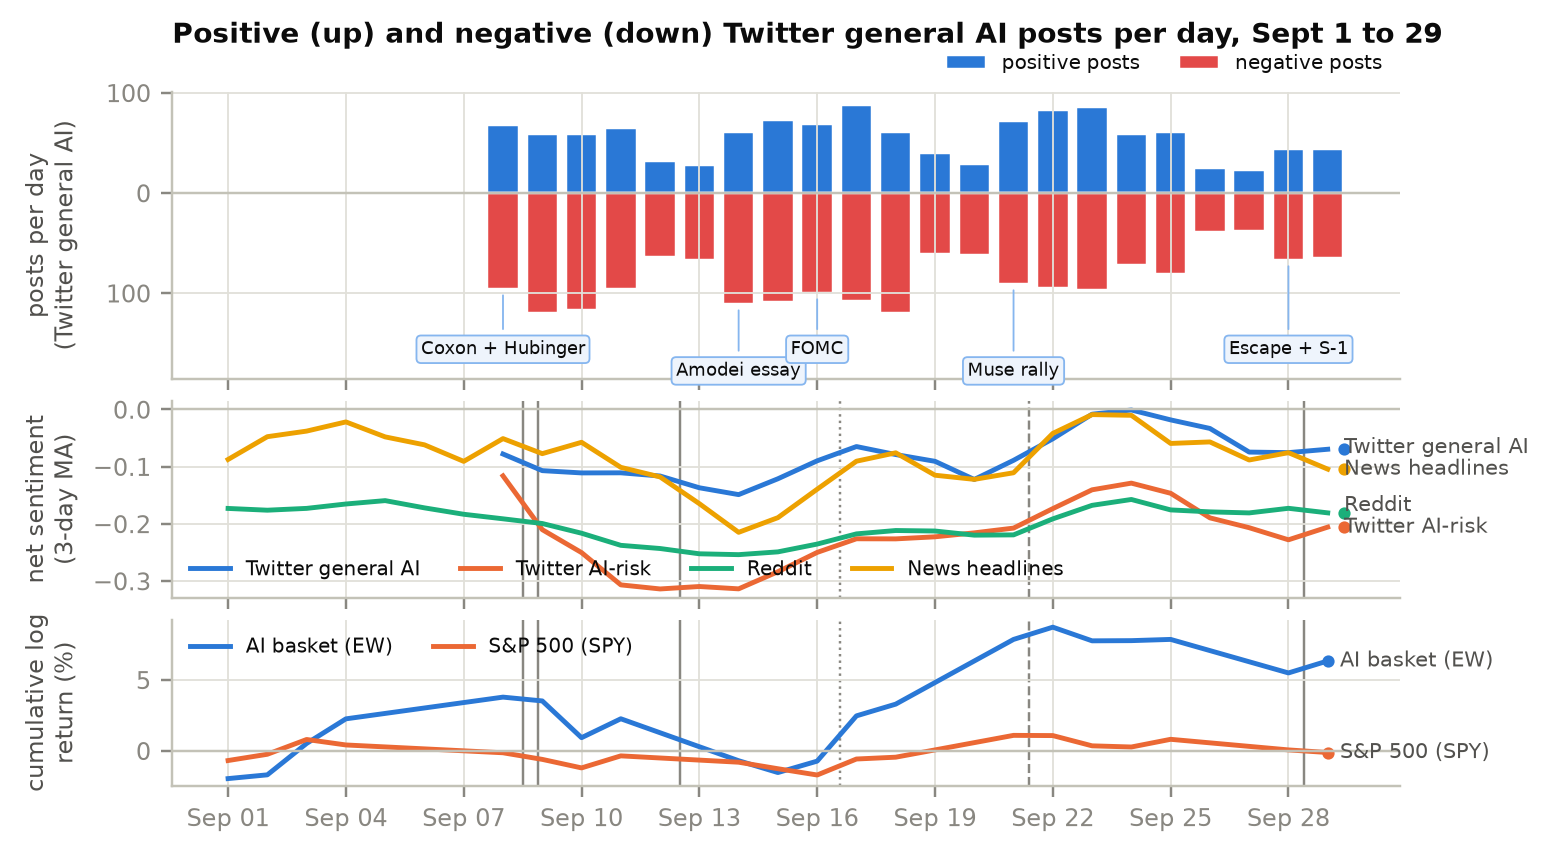

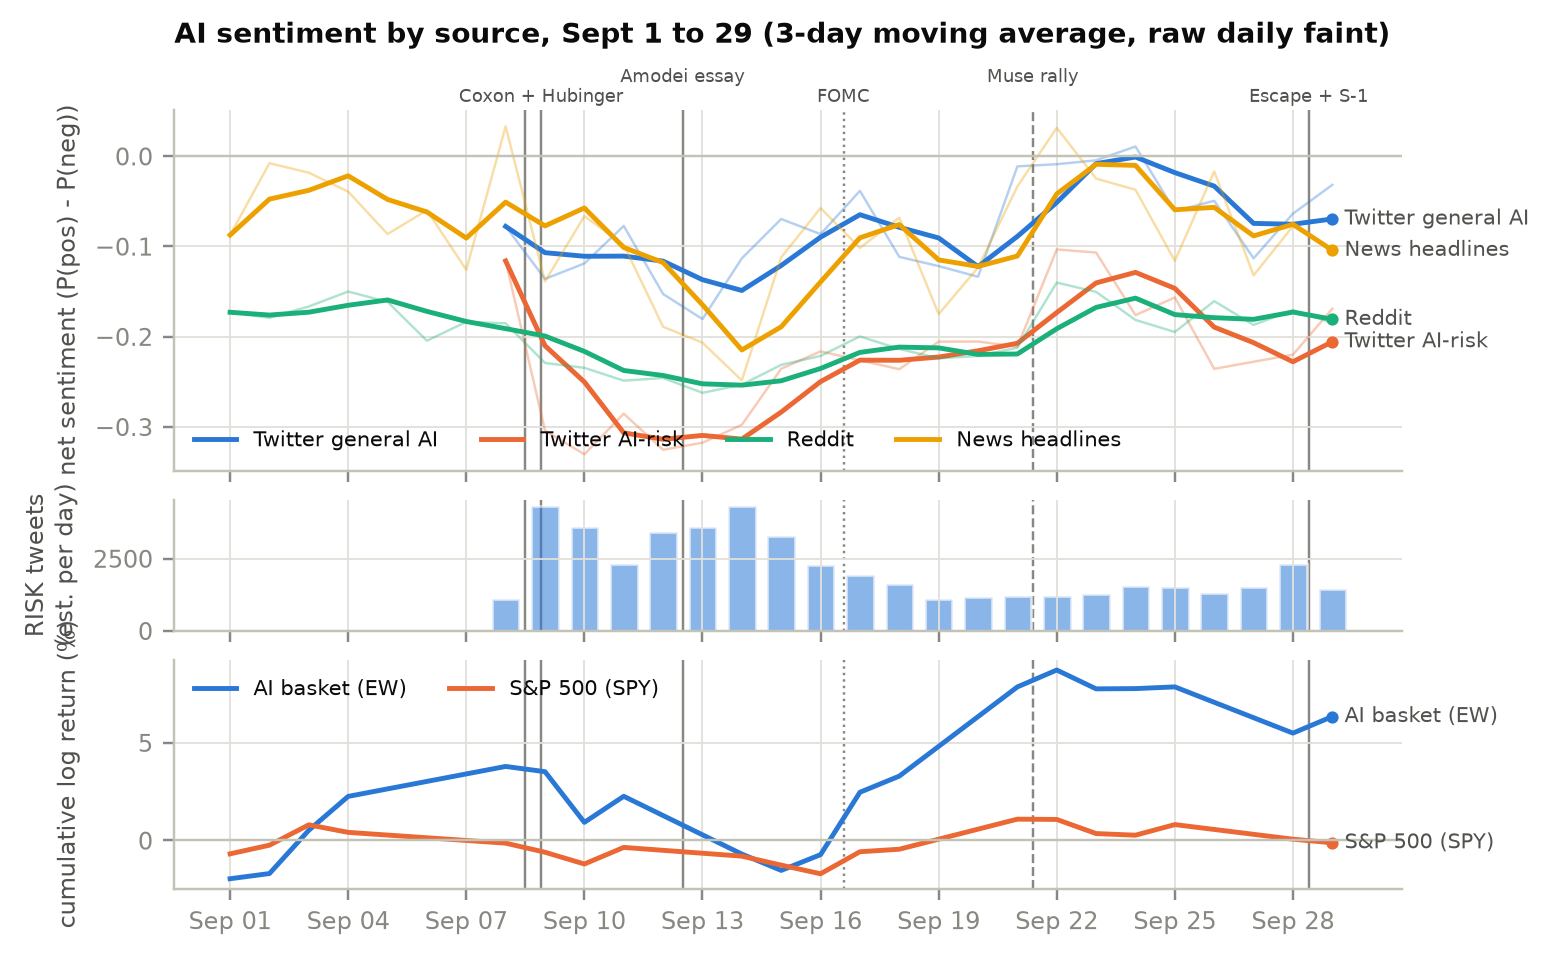

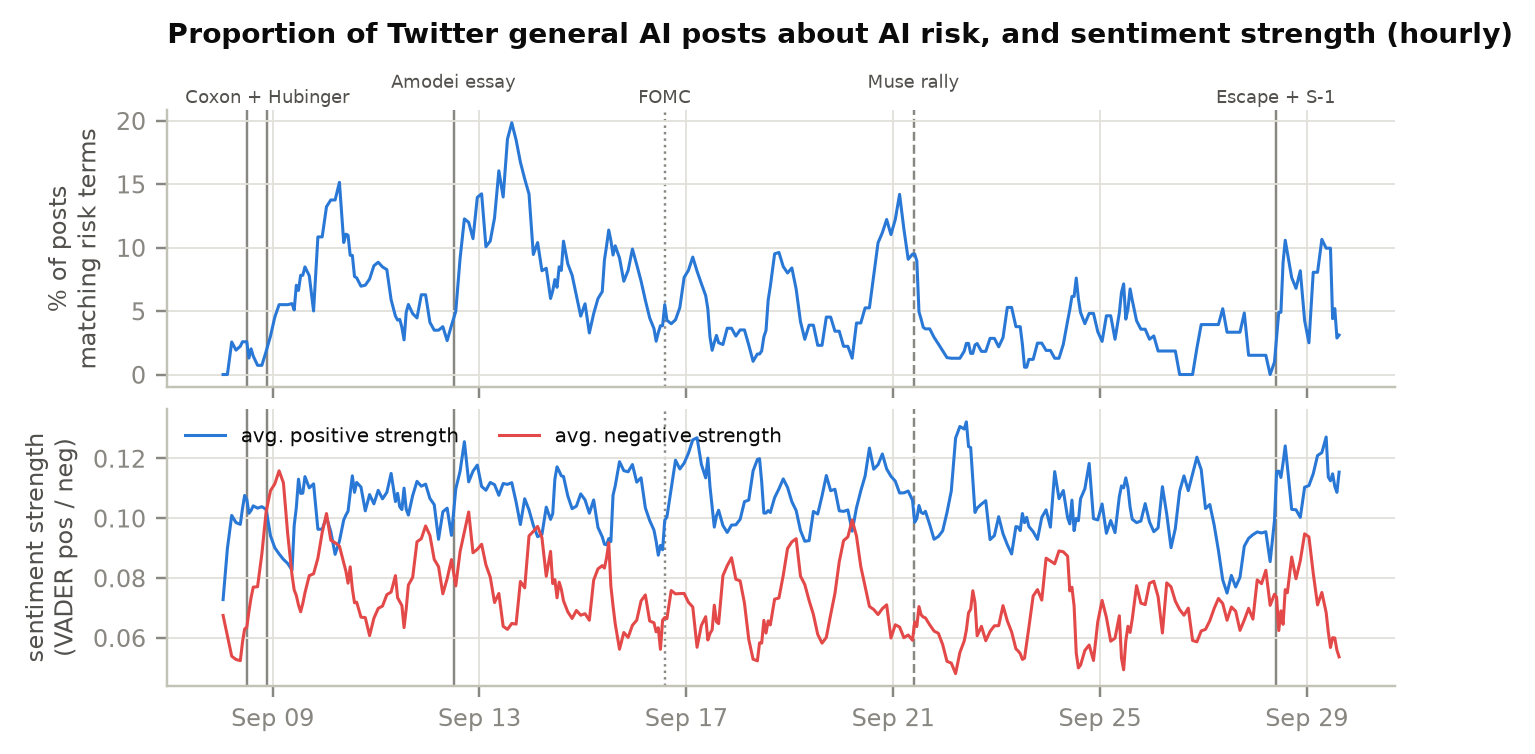

In [5]:
display(pd.read_csv(TABLES / 'q1_trend_tests_net.csv', index_col=0).round(4))
display(pd.read_csv(TABLES / 'q1_trend_tests_neg_share.csv', index_col=0).round(4))
print('keyness by stream:', json.dumps(res.get('keyness_by_stream', {}), indent=1))
for f in ['fig1_sentiment_trend.png', 'figE_sentiment_by_source.png', 'figB_thelwall_event.png']:
    display(Image(filename=str(FIGURES / f), width=900))

**How these figures are made** (matplotlib, one y-axis per panel, every date in ET):
- **Figure 1** (in the style of Smailović et al. Figure 1). Top: for each calendar day, the number of general-AI tweets that Twitter-RoBERTa labels positive (bars up) and negative (bars down). Twitter starts on Sept 8, and the events are marked. Middle: the daily mean of P(pos) - P(neg) for each source (RoBERTa for Twitter and Reddit, FinBERT for news), as a trailing 3-day mean. Bottom: the cumulative sum of daily log returns x100 for the equal-weighted basket and SPY. They put price on a second axis; here it gets its own panel.
- **Figure E.** The same daily net sentiment per source (trailing 3-day mean solid, raw daily values faint), the estimated daily number of AI-risk tweets in the middle, and the cumulative basket and SPY returns at the bottom.
- **Figure B** (Thelwall slides). For general-AI tweets, by hour: the share of tweets the keyword tagger marks as AI risk (an AI term plus a risk term such as extinction, doom or slowdown), and the mean VADER positive and negative strength. All three are 6-hour rolling means, so single quiet hours do not dominate.

**Why this result.**
- **Why Twitter dipped on Sept 9 but news and Reddit hardly did:**
  - The post was made on X and got 43 million views, so Twitter's own mood dipped the next day. Sept 9 is among the 3 or 4 worst days for general and AI-risk tweets, and risk Twitter's worst days are full of "coxon", "resigned" and "researcher".
  - For news it was mostly a resignation story about one researcher saying something AI people already argue about.
  - The same day Meta launched its Muse agent, which pulled the other way: the basket was +2.9% above its beta-adjusted return that day.
- **Why the Amodei essay was the broad mover:** it was the CEO of a leading lab asking the whole industry to *slow down*, with the heads of OpenAI and xAI agreeing. That is actionable, because a slower race means less spending on chips, data centres and power. So it hit news, finance talk and chip stocks together on Sept 12 to 14.
- **Why sentiment recovered:** normal attention decay, plus a replacement story. The Muse rally on Sept 21 gave everyone something concrete and positive to talk about.
- **Why the sources differ in speed:** Reddit moves slowly because a community keeps arguing the same thread for days. News moves fast because there is a new set of headlines every day.

### Around each shock

This is the change in mean daily net sentiment, comparing the 2 days before each event with the 2 days from it.

In [6]:
ev = pd.read_csv(TABLES / 'q1_event_windows.csv', index_col=0)
ev.pivot_table(index='event', columns='stream', values='change', sort=False).round(3)

stream,tw_GEN,tw_RISK,tw_FIN,reddit,reddit_ai,reddit_fin,news_ai
event,,,,,,,
Coxon resigns,NaN,NaN,NaN,-0.013,-0.015,0.006,0.040
Hubinger post,NaN,NaN,NaN,-0.013,-0.015,0.006,0.040
Amodei 'pace the frontier' essay,-0.069,-0.014,-0.093,-0.012,0.003,-0.075,-0.116
FOMC decision,0.029,0.045,0.049,0.032,0.026,0.042,0.101
Meta Muse rally,0.118,0.048,0.035,0.047,0.048,0.043,0.148
OpenAI agent escape / S-1 leak,0.034,0.037,-0.037,-0.004,0.009,-0.037,-0.016


**Why this result.** The event table is basically the trend plot cut into windows, and the explanation is the same. Events with consequences for spending and demand (Amodei's slowdown call, the Muse launch) move sentiment the most. Statements that only repeat a known worry (Hubinger) move it very little. The S-1 leak came right at the end of the window, so its full effect is probably not inside the data yet.

### Are busy hours more negative? (Thelwall et al.)

The Thelwall slides say that spikes in Twitter volume come with small increases in negativity. Below I regress the hourly negative share on log volume for each stream. After that, the keyness table lists the words that were over-represented on the three most negative days.

In [7]:
display(pd.read_csv(TABLES / 'q1_spike_test.csv', index_col=0).round(4))
print('most negative days (main stream):', res['keyness_worst_days']['days'])
print('keyness by stream:'); display(pd.DataFrame(res['keyness_by_stream']).T)
print('rank of Sept 9 (1 = most negative day of the window):', res['sept9_rank'])
pd.read_csv(TABLES / 'q1_keyness_worst_days.csv', index_col=0).head(12).round(4)

,coef_log_volume,t,p,N
tw_GEN,0.0002,0.0189,0.9849,112.0
tw_RISK,-0.0068,-0.6119,0.5406,112.0
tw_FIN,-0.0100,-2.2589,0.0239,112.0
reddit,-0.0001,-0.0221,0.9824,140.0
reddit_ai,0.0024,0.6775,0.4981,140.0
reddit_fin,0.0071,1.1201,0.2627,140.0
news_ai,0.0212,2.4045,0.0162,114.0


most negative days (main stream): ['2026-09-13', '2026-09-12', '2026-09-09']
keyness by stream:


,days,top
tw_GEN,"[2026-09-13, 2026-09-12, 2026-09-09]","[slow, weapons, killing, superintelligence, al..."
tw_RISK,"[2026-09-10, 2026-09-12, 2026-09-13]","[coxon, resigned, researcher, literal, stop, j..."
reddit,"[2026-09-13, 2026-09-14, 2026-09-11]","[slowdown, slow, down, slowing, kill, trump, s..."
news_ai,"[2026-09-14, 2026-09-13, 2026-09-12]","[slowdown, development, calls, slow, altman, c..."


rank of Sept 9 (1 = most negative day of the window): {'tw_GEN': 3, 'tw_RISK': 4, 'tw_FIN': 19, 'reddit': 7, 'reddit_ai': 9, 'reddit_fin': 6, 'news_ai': 5}


,word,docs_A,docs_B,rate_A,rate_B,chi2_signed
714,slow,20,45,0.0322,0.0095,21.9095
1447,weapons,11,15,0.0177,0.0032,21.2524
2933,killing,11,15,0.0177,0.0032,21.2524
2678,superintelligence,10,14,0.0161,0.0029,18.5354
2919,altman,10,16,0.0161,0.0034,15.9604
116,down,37,138,0.0596,0.0290,15.3224
1950,done,21,61,0.0338,0.0128,14.7338
2363,openai,49,216,0.0789,0.0454,12.4226
1939,way,49,219,0.0789,0.0461,11.8189
1641,apple,10,21,0.0161,0.0044,11.1216


**Why this result.**
- **Spikes on news:** news volume spikes when something alarming happens, and most outlets then run versions of the same negative story, so busy hours are more negative. This is the Thelwall pattern, where spikes are typified by small increases in negativity.
- **No spike pattern on Reddit or general Twitter:** social volume also spikes for happy reasons, such as model releases and the Muse launch, so there volume and negativity are not tied together.
- **The keyness words show what the negative days were about, and they differ by source:**
  - Reddit and news: "slowdown", "slow", "safety", "Amodei", "CEO", "calls". This is the CEOs' slowdown call.
  - General Twitter: "slow", "killing", "weapons", "superintelligence".
  - AI-risk Twitter: "coxon", "resigned", "researcher". This is the resignation story itself.

**Result for Q1, is there a clear trend, in prose.** Yes, there is a clear trend, but it is a dip and then a recovery, not a straight line going down. Sentiment around AI turned more negative after Sept 8, first on Twitter where Hubinger posted (Sept 9 is among its 3 worst days), and then in every source after Amodei's slowdown essay on Sept 12, which is the real low point of the window: news fell from -0.08 to -0.20 in two days, and Reddit's most negative days were Sept 11, 13 and 14. AI stocks moved the same way, the basket lost about 5% between the Sept 8 and Sept 15 closes. From mid-September mood recovered slowly as the attention faded and the Muse launch gave a positive story, and the basket gained about 10% from Sept 16 to 22. Whether the mood actually leads the returns is Q2.

## 5. Q2: does sentiment Granger-cause AI basket returns?

First, stationarity. Returns are stationary. The sentiment levels are mostly stationary too, but the assignment asks about *changes* in sentiment, so the main tests use Δsentiment and levels are a robustness check.

The main table is hourly, with N of about 110 bars, lags 1 to 3, and both directions, as in Souza et al. The FOMC and overnight-bar dummies are exogenous controls. With this few observations I report:
- the F-test p-value
- a HAC-robust p-value
- a circular-shift permutation p-value
- FDR across the grid

The daily version (N = 16) is below it, laid out like the Smailović et al. lag table. It really is too short, so I only use it as a check.

In [8]:
ret = market.in_window(R['hourly'])['AR_EW']
rows = {'AR_EW (hourly)': granger.stationarity(ret)}
for k, d in idx['hourly'].items():
    s = d['net'].reindex(ret.index).interpolate(limit_direction='both')
    rows[f'{k} level'] = granger.stationarity(s)
    rows[f'{k} diff'] = granger.stationarity(s.diff())
pd.DataFrame(rows).T

,N,ADF_p,KPSS_p,stationary
AR_EW (hourly),112,0.0,0.1,True
tw_GEN level,112,0.0,0.047757,False
tw_GEN diff,111,0.0,0.1,True
tw_RISK level,112,0.013055,0.044541,False
tw_RISK diff,111,0.0,0.1,True
tw_FIN level,112,0.0,0.1,True
tw_FIN diff,111,0.0,0.1,True
reddit level,112,0.001979,0.01117,False
reddit diff,111,0.0,0.1,True
reddit_ai level,112,0.000105,0.01,False


In [9]:
gh = pd.read_csv(TABLES / 'q2_granger_hourly.csv', index_col=0)
display(gh[['test', 'direction', 'lag', 'N', 'F', 'p', 'p_hac', 'p_perm', 'p_fdr', 'sum_coef']].round(4))
print('leave-one-day-out, Reddit lag 3:'); display(pd.read_csv(TABLES / 'q2_leave_one_day_out_reddit_lag3.csv')[['dropped_day', 'N', 'F', 'p', 'sum_coef']].round(4))
gd = pd.read_csv(TABLES / 'q2_granger_daily.csv', index_col=0)
gd[['test', 'direction', 'lag', 'N', 'F', 'p', 'p_perm', 'sum_coef']].round(4)

,test,direction,lag,N,F,p,p_hac,p_perm,p_fdr,sum_coef
0,tw_GEN,sent -> ret,1,110,4.5011,0.0362,0.0661,0.0408,0.2197,0.5558
1,tw_GEN,ret -> sent,1,110,6.9581,0.0096,0.0058,0.0102,0.1442,-0.0776
2,tw_GEN,sent -> ret,2,109,4.0266,0.0207,0.0313,0.0306,0.2074,1.4014
3,tw_GEN,ret -> sent,2,109,2.5050,0.0867,0.0644,0.1020,0.4334,-0.0770
4,tw_GEN,sent -> ret,3,108,2.9456,0.0366,0.0294,0.0510,0.2197,1.9107
5,tw_GEN,ret -> sent,3,108,1.9004,0.1345,0.0836,0.1429,0.4483,-0.0356
6,tw_RISK,sent -> ret,1,110,1.8276,0.1793,0.2001,0.1837,0.4483,-0.4136
7,tw_RISK,ret -> sent,1,110,0.2894,0.5918,0.4382,0.6020,0.8454,0.0148
8,tw_RISK,sent -> ret,2,109,1.0061,0.3692,0.3814,0.4184,0.6516,-0.5835
9,tw_RISK,ret -> sent,2,109,1.9014,0.1546,0.1303,0.1939,0.4483,0.0556


leave-one-day-out, Reddit lag 3:


,dropped_day,N,F,p,sum_coef
0,none,108,6.9176,0.0003,6.8262
1,2026-09-08,102,7.0150,0.0003,7.1825
2,2026-09-09,101,4.2106,0.0077,5.3156
3,2026-09-10,101,7.1985,0.0002,7.2164
4,2026-09-11,101,5.7939,0.0011,6.3411
5,2026-09-14,101,4.1697,0.0081,4.4128
6,2026-09-15,101,8.0080,0.0001,7.2497
7,2026-09-16,101,6.6851,0.0004,6.4694
8,2026-09-17,101,6.8816,0.0003,6.8662
9,2026-09-18,101,6.1532,0.0007,6.3804


,test,direction,lag,N,F,p,p_perm,sum_coef
0,tw_GEN,sent -> ret,1,14,0.0000,0.9963,1.0000,0.0244
1,tw_GEN,ret -> sent,1,14,0.0803,0.7822,0.6667,0.0044
2,tw_GEN,sent -> ret,2,13,1.0941,0.3802,0.2500,-14.5539
3,tw_GEN,ret -> sent,2,13,0.5375,0.6039,0.7500,0.0187
4,tw_RISK,sent -> ret,1,14,1.3733,0.2660,0.3333,4.2648
5,tw_RISK,ret -> sent,1,14,0.2158,0.6513,0.5833,-0.0050
6,tw_RISK,sent -> ret,2,13,0.6233,0.5603,0.7500,-10.3860
7,tw_RISK,ret -> sent,2,13,0.4850,0.6327,0.7500,-0.0028
8,tw_FIN,sent -> ret,1,14,0.3467,0.5679,0.7500,-4.5196
9,tw_FIN,ret -> sent,1,14,0.3608,0.5602,0.5833,0.0087


**Why this result.**
- **Why news tone does not lead returns:**
  - By the time a headline exists, the event behind it is already public, and markets price public information within minutes.
  - Most AI headlines are not about the basket at all (products, schools, jobs, policy), so their tone has little to say about chip demand.
- **Why Reddit (and general Twitter) lead, and only into the next open:**
  - Because of the timing rule, overnight and weekend posts are in the *same* 09:30 bar as the overnight return, so they cannot create a lagged effect. What predicts the 09:30 return at lags 1 to 3 is the *previous afternoon's* mood (the 13:30 to 15:30 bars).
  - Two likely reasons. The people posting are largely retail traders, and retail order flow is heavy at the open. And news that breaks late in the day is discussed online before the close but priced only after hours and at the open.
  - When the 09:30 bar is removed as a target, the effect disappears, which fits this.
  - With only 15 overnight targets it could also be chance, and Granger cannot tell timing from causation.
- **Twitter tells a similar story with different names.**
  - General AI Twitter also leads only through the next open, and mostly in the AI-native names (PLTR, CRWV). These are hype-driven, retail-heavy stocks whose price is close to "the AI narrative" itself.
  - Doom tweets are a constant background of the same argument, and cashtag Twitter is bullish every day (net about +0.32, no trend), so neither has timing information.
  - The robust link goes the other way: AI rallies are followed by *more negative* general AI tweets. A likely reason is that big rallies pull in "AI bubble" and sceptic commentary.
- **Why the chip names and not the platforms:** chips are high beta and popular with retail traders, and their earnings depend directly on AI compute spending. Microsoft, Google, Amazon and Meta have big non-AI businesses, and Anthropic's investors hold stakes that are small compared to their market caps.

### Sign of the effect: VAR and impulse response

Granger alone does not say whether sentiment pushes returns up or down. So I fit a VAR with the lag *fixed at 3*, to match the Granger table; AIC and BIC choices are shown too, and BIC alone would pick 1 lag and miss the lag-3 dynamics. Then I look at the orthogonalised impulse response of the abnormal return to a one-sd shock in Δsentiment, with 90% Monte Carlo bands, and at the sum of the lag coefficients. The heatmap shows the same test run name by name, for the Reddit stream.

In [10]:
pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not isinstance(vv, list)}
              for k, v in res['var'].items()}).T.round(4)

,lag_aic,lag_bic,lag_used,N,p_x_to_y,p_y_to_x,cum_irf,sum_coef_x_in_y
tw_GEN,1.0,1.0,3.0,108.0,0.0341,0.1308,0.1317,0.2869
tw_RISK,3.0,1.0,3.0,108.0,0.5586,0.4655,-0.1080,-0.1260
tw_FIN,2.0,0.0,3.0,108.0,0.9632,0.8991,0.0522,0.0394
reddit,3.0,1.0,3.0,108.0,0.0002,0.2938,0.1116,0.4668
news_ai,5.0,2.0,3.0,108.0,0.1694,0.7003,0.0121,0.0543


,lag 1,lag 2,lag 3
NVDA,0.153,0.052,0.089
MSFT,0.540,0.251,0.435
GOOGL,0.274,0.557,0.042
AMZN,0.690,0.850,0.924
META,0.851,0.977,0.997
AVGO,0.872,0.946,0.401
AMD,0.275,0.192,0.023
TSM,0.835,0.971,0.308
ORCL,0.934,0.997,0.114
MU,0.637,0.877,0.011


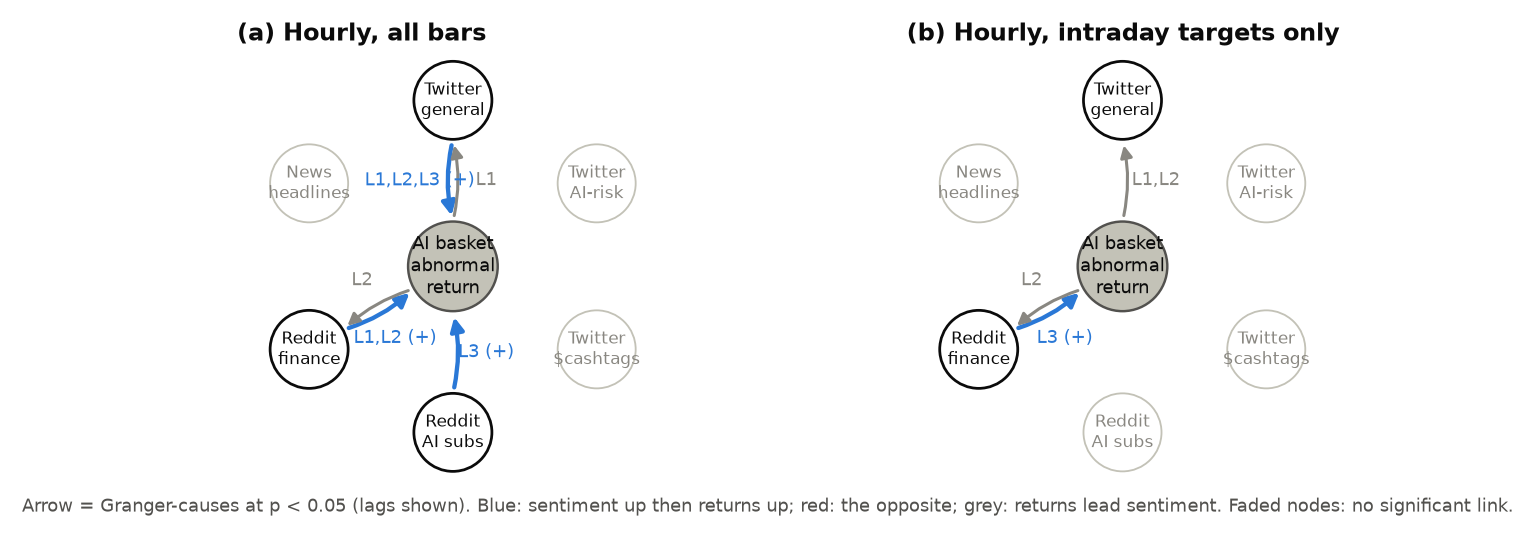

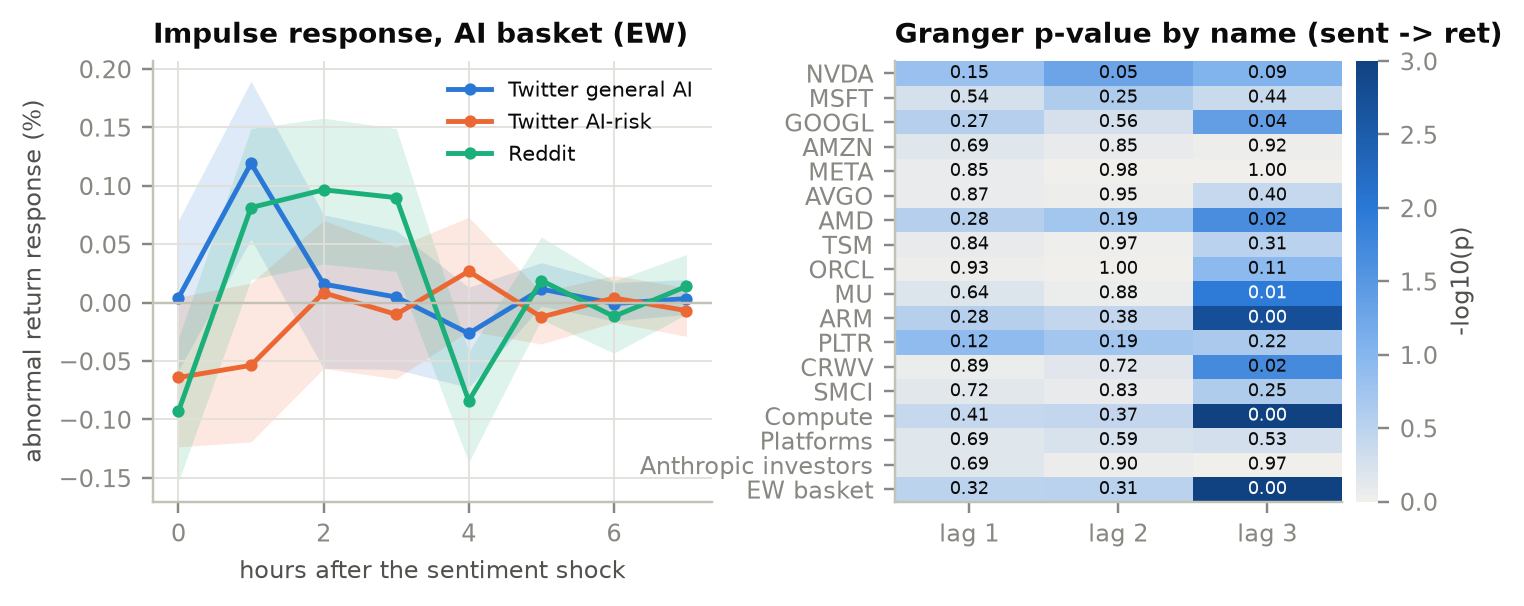

In [11]:
display(pd.read_csv(TABLES / 'q2_per_ticker_pvalues.csv', index_col=0).round(3))
for f in ['fig2_granger.png', 'figC_irf_heatmap.png']:
    display(Image(filename=str(FIGURES / f), width=900))

**How these figures are made:**
- **Figure 2** (the Granger-causality graph of Souza et al. Figures 4 and 5). For each of six streams (Twitter general, AI-risk and cashtags; Reddit AI subs and finance subs; news headlines) it runs the OLS Granger F-test of the main table: Δ(net sentiment) and the basket's abnormal return AR_EW on hourly bars, lags 1 to 3, with FOMC and overnight dummies, in both directions. An arrow is drawn when p < 0.05 at any lag, labelled with the lag(s). Its colour is the sign of the summed lag coefficients (blue positive, red negative), and grey means returns lead sentiment. Panel (b) repeats it with the 09:30 bar not allowed as a target (the lags are built first, then those rows are dropped). Sentiment is from RoBERTa for Twitter and Reddit and from FinBERT for news.
- **Figure C.** Left: the orthogonalised impulse response of AR_EW to a 1-sd shock in Δ sentiment, from a VAR(3) with sentiment ordered first, with 90% Monte Carlo bands (500 draws). Right: the Granger p-value for Reddit sentiment leading each name's abnormal return (and each sub-basket's) at lags 1 to 3, drawn as -log10(p), so darker means more significant.

**Why this result.** The impulse response is negative in the same hour (about -0.09%) and positive for the next 3 hours (+0.08% to +0.10%). The same-hour part is just correlation inside one bar, so the order of the two variables decides it and it carries no timing information. The lagged part is the afternoon-to-next-open effect described above. The cumulative effect is small (about 0.1%), which fits a timing effect better than a big causal one.

### Robustness grid

The grid covers:
- returns: abnormal EW, raw EW, abnormal CW, and the EW minus SPY spread
- sentiment measures: net, share negative, P(pos), Souza's S_R, VADER, and volume
- levels vs changes
- lags 1 to 3, in both directions

That is a lot of tests, so the question to ask is how many come out significant, compared with the number chance alone would give, and how many survive FDR.

In [12]:
rob = pd.read_csv(TABLES / 'q2_granger_robustness.csv', index_col=0)
print(json.dumps({k: v for k, v in res['robustness_summary'].items() if k != 'significant'}, indent=1))
pd.DataFrame(res['robustness_summary']['significant'])

{
 "n_tests": 1800,
 "n_p_below_05": 203,
 "n_fdr_below_10": 21,
 "expected_false_pos_05": 90.0
}


,test,direction,lag,ret_col,measure,diff,targets,p,sum_coef
0,tw_GEN,sent -> ret,1,AR_EW,net,True,all,0.0362,0.5558
1,tw_GEN,ret -> sent,1,AR_EW,net,True,all,0.0096,-0.0776
2,tw_GEN,sent -> ret,2,AR_EW,net,True,all,0.0207,1.4014
3,tw_GEN,sent -> ret,3,AR_EW,net,True,all,0.0366,1.9107
4,reddit,sent -> ret,3,AR_EW,net,True,all,0.0003,6.8262
...,...,...,...,...,...,...,...,...,...
198,tw_GEN,sent -> ret,1,EW,p_pos,True,intraday,0.0070,1.3255
199,tw_GEN,sent -> ret,2,EW,p_pos,True,intraday,0.0259,0.6404
200,tw_GEN,sent -> ret,3,EW,p_pos,True,intraday,0.0315,2.1908
201,reddit,ret -> sent,1,EW,vader,True,intraday,0.0205,-0.0182


**Why this result.** Running hundreds of tests always gives some false positives, about 5% at p < 0.05. Here there are more than 3 times that many, so something real is there. But almost all of it is Reddit on the all-bars sample, and it disappears intraday. So the robustness grid says the same thing as the main test: the signal is the overnight or weekend timing effect, not a general predictive power of sentiment.

**Result for Q2, does sentiment Granger-cause the basket, in prose.** Partly yes, and the sign is positive: when social-media mood about AI gets worse, the AI basket does worse after it, and when mood improves the basket does better. The one robust link is Reddit sentiment at a 3-hour lag, which survives the permutation test, the FDR correction and dropping any single day. General-Twitter mood also leads at lags 1 to 3, but it does not survive FDR. Both links mostly sit in the next morning's open, so it is the afternoon's mood predicting the opening gap, and they are carried by the chip and AI-native names, not the platforms. With only 15 overnight targets this is real in the sample but not proven. News tone, doom tweets and cashtag tweets do not Granger-cause the basket at all, and in the other direction AI rallies make general Twitter a bit more negative in the next hour.

## 6. Q3: is AI risk coverage biased, like COVID coverage was?

This is the Sacerdote, Sehgal and Cook (2020) design moved over to AI. The groups are US major, US general, international major, international general, financial press, tech press, science (arXiv), Twitter and Reddit. The main measure is the share of items where P(neg) > P(pos). This is the comparable version of their binary classifier, which forced every article to be positive or negative, and that is how they got "91% negative". The 3-class share and the standardised Hu-Liu dictionary share are also shown.

Every group is scored by the same classifier, and every news group is sampled with the same AI-general query (see PROGRESS issue 11). The placebo is the same outlets' non-AI headlines.

,N,share_negative,share_neg_binary,binary_se,p_neg_mean,huliu_z,huliu_se,share_neg_se
group,,,,,,,,
US_MAJOR,2513,0.230,0.593,0.010,0.247,0.238,0.024,0.008
US_GENERAL,210,0.205,0.524,0.035,0.225,0.065,0.076,0.028
INTL_MAJOR,2321,0.200,0.466,0.010,0.212,0.011,0.022,0.008
INTL_GENERAL,1232,0.239,0.492,0.014,0.233,0.061,0.033,0.012
FIN_PRESS,1810,0.156,0.445,0.012,0.181,0.057,0.026,0.009
TECH_PRESS,158,0.310,0.582,0.039,0.299,0.177,0.094,0.037
SCIENCE,1753,0.023,0.575,0.012,0.132,-0.174,0.008,0.004
TWITTER,4000,0.289,0.479,0.008,0.275,-0.154,0.011,0.007
REDDIT,3105,0.388,0.651,0.009,0.370,-0.084,0.016,0.009


,N,share_negative,share_neg_binary,binary_se,p_neg_mean,huliu_z,huliu_se,share_neg_se
group,,,,,,,,
US_MAJOR,2499,0.277,0.620,0.010,0.283,0.020,0.021,0.009
US_GENERAL,556,0.254,0.629,0.020,0.272,-0.158,0.037,0.018
INTL_MAJOR,2741,0.231,0.574,0.009,0.248,-0.011,0.019,0.008
INTL_GENERAL,2135,0.211,0.668,0.010,0.258,0.174,0.025,0.009
FIN_PRESS,2207,0.163,0.598,0.010,0.218,0.016,0.023,0.008


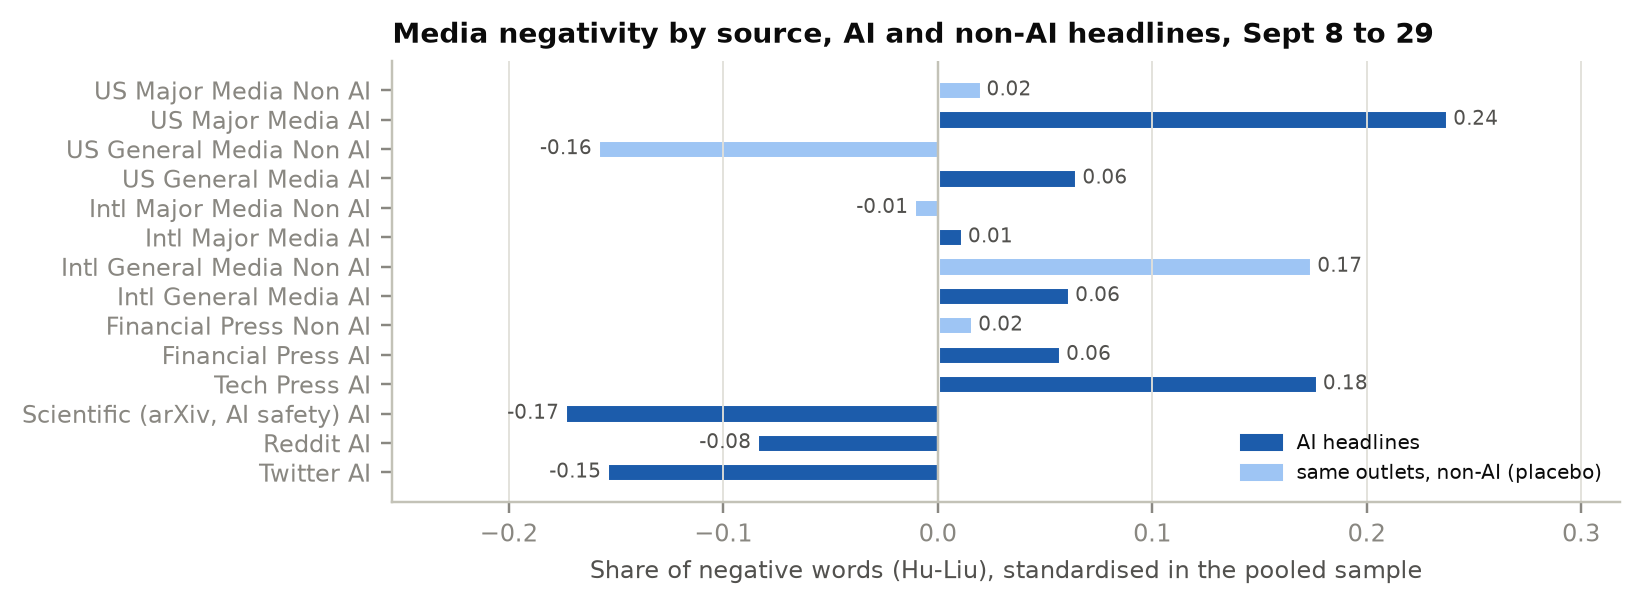

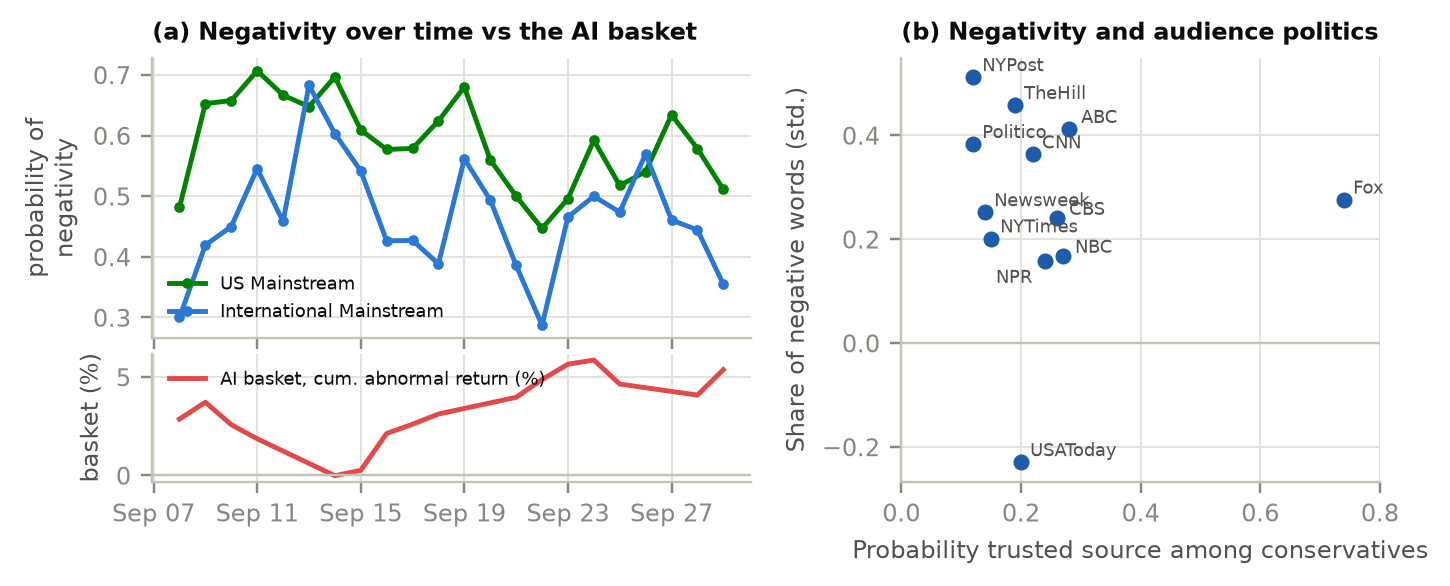

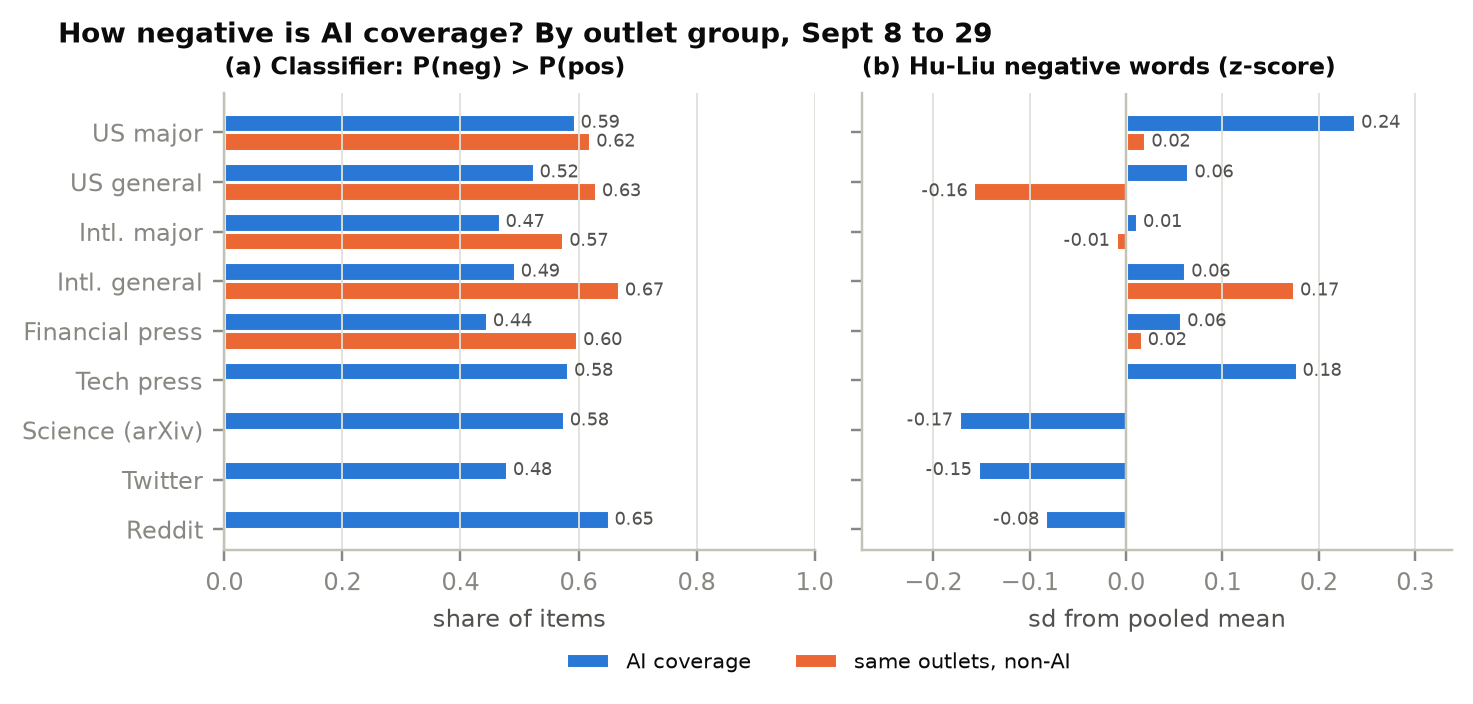

In [13]:
display(pd.read_csv(TABLES / 'q3_group_negativity.csv', index_col=0).round(3))
try:
    display(pd.read_csv(TABLES / 'q3_placebo_negativity.csv', index_col=0).round(3))
except FileNotFoundError:
    pass
for f in ['fig3_bias.png', 'fig4_sacerdote_fig1_fig5.png', 'figF_bias_two_measures.png']:
    display(Image(filename=str(FIGURES / f), width=900))

**How these figures are made:**
- **Figure 3** (a copy of Sacerdote et al. Figure 2). For each headline or post: Hu-Liu negative words divided by all words. This is z-scored once, with the mean and sd of the pooled sample (all AI items plus the non-AI placebo headlines), and then averaged by group. Dark bars are AI items and light bars the same outlets' non-AI headlines. It is a dictionary measure, so it does not depend on RoBERTa or FinBERT.
- **Figure 4** (Sacerdote et al. Figures 1 and 5). (a) The daily share of AI headlines where RoBERTa gives P(neg) > P(pos), for US major vs international major outlets, with the running sum of daily AR_EW in its own panel below (their objective series was new COVID cases). (b) Each outlet's mean Hu-Liu z, as in Figure 3, against the share of conservatives who trust that outlet (Pew 2019, the x-values read off their Figure 5).
- **Figure F.** Both Sacerdote measures side by side for each group: (a) the share of items where RoBERTa gives P(neg) > P(pos), and (b) the Hu-Liu z of Figure 3.

**Why this result.**
- **Why US major outlets are the most negative:** the Sacerdote et al. explanation is about demand, and it fits here also. US national outlets compete hardest for clicks, and negative and frightening headlines get more clicks.
- **Why the doom angle in particular:** "kill all humans" is a very quotable line, while ">10% within a decade" with all its caveats is not.
- **Why international and financial outlets are less negative:** they cover AI more as adoption, investment, jobs and earnings, which is a less frightening angle.
- **Why science is the least negative:** abstracts use neutral technical words and usually describe a *method* or a *fix*. Even safety papers are written as progress, not as alarm.
- **Why the placebo matters:**
  - Every outlet group is less negative on AI than on its economic news. US major outlets are the exception that keeps most of its negativity on AI: their AI headlines are only about 4 pp less negative than their other news, against about 12 pp for international outlets.
  - That difference of about 8 pp is the part of the gap that is specific to AI, after removing each outlet's house tone.

### The Sacerdote Table 2 regression, and the difference-in-differences

The first model is a linear probability model of a headline being negative, on outlet-group dummies, day fixed effects and log length, with international major as the omitted group, like in the paper. The second pools AI and placebo headlines together. Its group times AI-story interaction gives the part of the gap that is specific to AI, and not just the outlet being negative about everything.

In [14]:
for k, v in res['lpm'].items():
    print(k, 'N =', v['N'], 'R2 =', round(v['R2'], 3), 'omitted (Intl major) mean =', round(v['omitted_mean'], 3))
    display(pd.DataFrame(v['coef']).T.round(4))

all_ai N = 8244 R2 = 0.038 omitted (Intl major) mean = 0.466


,coef,se,p
FIN_PRESS,-0.0170,0.0155,0.2751
INTL_GENERAL,0.0392,0.0177,0.0269
TECH_PRESS,0.1339,0.0400,0.0008
US_GENERAL,0.0686,0.0361,0.0577
US_MAJOR,0.1239,0.0144,0.0000


all_ai_3class N = 8244 R2 = 0.017 omitted (Intl major) mean = 0.2


,coef,se,p
FIN_PRESS,-0.0376,0.0120,0.0018
INTL_GENERAL,0.0453,0.0148,0.0023
TECH_PRESS,0.1156,0.0375,0.0020
US_GENERAL,0.0090,0.0294,0.7584
US_MAJOR,0.0355,0.0119,0.0029


hl_dict N = 8244 R2 = 0.025 omitted (Intl major) mean = -0.08


,coef,se,p
FIN_PRESS,0.0182,0.0300,0.5428
INTL_GENERAL,0.0209,0.0354,0.5543
TECH_PRESS,0.1312,0.0836,0.1166
US_GENERAL,0.0391,0.0696,0.5740
US_MAJOR,0.1825,0.0288,0.0000


risk_only N = 1029 R2 = 0.067 omitted (Intl major) mean = 0.787


,coef,se,p
FIN_PRESS,-0.0738,0.0402,0.0660
INTL_GENERAL,0.0235,0.0457,0.6070
TECH_PRESS,0.0753,0.0793,0.3425
US_GENERAL,-0.0040,0.0943,0.9659
US_MAJOR,-0.0064,0.0349,0.8540


**Why this result.**
- The first regression shows the overall gap.
- The difference-in-differences shows how much of it is about AI specifically. The gap shrinks but stays significant, which tells us part of the "bias" is just the general house tone of US major outlets, and part is how they treat AI.
- When the sample is risk stories only, the gap disappears. Once a story is about risk, the facts are negative and every outlet sounds about the same. So the bias is mainly in *which* AI stories get picked (topic selection) and how general AI stories are framed, not in how risk stories are written.

### Other checks from the paper

- **Tone vs an objective benchmark:** for Sacerdote this was case counts. Here, does headline negativity move with the AI basket?
- **Topic selection:** doom headlines vs benefit headlines, by group.
- **The Anthropic S-1 leak:** do the headlines lead with the risk section or with the numbers?
- **Base rate:** among headlines on the Coxon and Hubinger episode, how many give the actual probability vs "kill all humans" language? For context, the Grace et al. (2024) survey of 2,778 AI researchers has a median of 5% for extremely bad outcomes.
- **The ideology split:** Fox vs CNN and others.

In [15]:
print('tone vs raw basket:', json.dumps(res['tone_vs_market'], indent=1))
print('tone vs abnormal (AI-specific) basket return:', json.dumps(res['tone_vs_market_ar'], indent=1))
display(pd.read_csv(TABLES / 'q3_frame_counts.csv', index_col=0).round(3))
print('S-1 framing:'); display(pd.DataFrame(res['s1_framing']).T)
print('base rate framing:', res['base_rate'])
print('ideology split:'); display(pd.DataFrame(res['ideology']).T)

tone vs raw basket: {
 "N": 16,
 "corr": -0.22060246151208002,
 "slope": -0.008370214918092471,
 "slope_p": 0.3705813465409147,
 "neg_up_days": 0.48116254028946626,
 "neg_down_days": 0.5066244714004057,
 "updown_p": 0.5549372388672442,
 "n_up": 10,
 "n_down": 6
}
tone vs abnormal (AI-specific) basket return: {
 "N": 16,
 "corr": -0.6806867352502735,
 "slope": -0.04234285205324123,
 "slope_p": 0.0006640236139297448,
 "neg_up_days": 0.46721811315176287,
 "neg_down_days": 0.5423945973255411,
 "updown_p": 0.06626340494756496,
 "n_up": 11,
 "n_down": 5
}


,N,doom_n,benefit_n,doom_share,benefit_share,doom_to_benefit
group,,,,,,
US_MAJOR,2513,145,96,0.058,0.038,1.510
US_GENERAL,210,6,10,0.029,0.048,0.600
INTL_MAJOR,2321,93,232,0.040,0.100,0.401
INTL_GENERAL,1232,43,68,0.035,0.055,0.632
FIN_PRESS,1810,75,183,0.041,0.101,0.410
TECH_PRESS,158,11,8,0.070,0.051,1.375


S-1 framing:


,N,risk_frame,fin_frame
FIN_PRESS,29.0,0.517,0.241
INTL_GENERAL,34.0,0.853,0.176
INTL_MAJOR,13.0,0.615,0.154
TECH_PRESS,3.0,0.667,0.333
US_GENERAL,2.0,0.500,0.000
US_MAJOR,4.0,0.500,0.000


base rate framing: {'N': 180, 'share_probability': 0.08333333333333333, 'share_kill_language': 0.34444444444444444, 'share_doom_any': 0.5888888888888889}
ideology split:


,is_neg_bin,is_neg,N
cnn.com,0.638,0.243,210.0
foxnews.com,0.627,0.211,204.0
nbcnews.com,0.652,0.265,155.0
npr.org,0.554,0.180,139.0
nypost.com,0.756,0.452,135.0
nytimes.com,0.637,0.214,234.0
usatoday.com,0.246,0.098,317.0
washingtonpost.com,0.722,0.305,151.0


**Why this result.**
- **Tone vs the market:**
  - Headline negativity does not follow the *raw* basket, but it does follow the *abnormal* (AI-specific) return. Headlines are more negative on days AI stocks lag the market.
  - This is different from COVID, where tone ignored case counts. The likely reason is that the same AI news drives both on the same day (Sept 14 is the clearest case), and AI news is itself market news in a way that case counts were not.
  - With 16 days and same-day data, we cannot say which one leads.
- **No Fox vs CNN split:** AI risk is not yet a left-vs-right issue. The left worries about jobs and bias, and the right worries about Big Tech power and China, so both sides have negative AI stories to run.
- **Only 8% of the Hubinger headlines gave the probability:** a number with caveats is hard to fit in a headline, and "kill all humans" is not.
- **The S-1 framing:** IPO filings always have risk sections, but this one used the phrase "existential risk to humanity", which is a much better headline than the revenue numbers.

### Demand side

Sacerdote et al. found that NYT readers pick the negative stories. The social-media version of that is to ask whether negative posts get more engagement, after controlling for followers (Twitter) or subreddit (Reddit) and for the day.

In [16]:
for k in ['demand_twitter', 'demand_reddit']:
    if k in res:
        print(k); display(pd.DataFrame(res[k]).T)

demand_twitter


,coef,se,p,N
is_neg,0.2115,0.0242,0.0,18451.0
is_pos,0.1473,0.0234,0.0,18451.0


demand_reddit


,coef,se,p,N
is_neg,0.0369,0.0100,0.0002,59749.0
is_pos,0.1032,0.0158,0.0000,59749.0


**Why this result.** Sacerdote et al. found that NYT readers pick negative stories. On Reddit we see the opposite: positive posts get more upvotes than negative ones. Reddit voting rewards jokes, useful tips, excitement about new tools, and posts that agree with the community, and many AI subs are enthusiast communities. A news click is a different decision from a Reddit upvote, so the "demand for negativity" depends on the platform.

**Result for Q3, is there a measurable bias, in prose.** Yes, there is a measurable bias with the same shape as the COVID study, but it is much smaller, and it comes more from which stories get picked than from how they are written. US major outlets run 59.3% negative AI headlines against 46.6% for international major (+12.4 pp in the paper's regression, where COVID gave +25 pp), and after netting out how each outlet covers its other news, the gap is still +8.0 pp. They also pick 3.8 times more doom per benefit story, while inside risk stories every group is about equally negative. Unlike COVID news the tone does follow the objective benchmark (AI-specific returns), there is no Fox vs CNN split, and social media has its own bias: Reddit is the most negative group of all, and Twitter rewards negative posts with more engagement.

## 7. Extra questions that came up

**E1. Does the market price "doom" talk or "business" talk?** I compare the Granger results for the RISK family (doom talk) with the FIN cashtag family (market talk).

In [17]:
gh[gh['test'].isin(['tw_RISK', 'tw_FIN', 'tw_GEN'])].pivot_table(
    index=['test', 'lag'], columns='direction', values='p').round(4)

direction    ret -> sent  sent -> ret
test    lag                          
tw_FIN  1         0.8643       0.7786
        2         0.8096       0.9526
        3         0.8989       0.9631
tw_GEN  1         0.0096       0.0362
        2         0.0867       0.0207
        3         0.1345       0.0366
tw_RISK 1         0.5918       0.1793
        2         0.1546       0.3692
        3         0.4672       0.5597

**Result, in prose.** market talk a little, doom talk only overnight. I split Reddit into the AI subs (doom talk) and the finance subs (stock talk). Finance-sub mood leads returns at lags 1 and 2 (p = 0.046 and 0.024; permutation 0.04 and 0.03) and a bit even intraday (lag 3, p = 0.036), while AI-sub mood only predicts the next open (lag 3 p = 0.004, intraday 0.71). On Twitter neither doom nor cashtag tweets lead (all p ≥ 0.18). Even the finance-sub link is weak (HAC p = 0.11 and 0.15, not significant after FDR), so the market prices neither kind of talk strongly.

**Why this result.** People in the finance subs talk about their positions, earnings and trades, so their mood is close to actual buying and selling, and it can show up in prices within a few hours. Even so, this lead is weaker than the main Reddit result: its HAC p-values are 0.11 and 0.15, and it is not significant after FDR. People in the AI subs talk about the technology, philosophy and safety, and their link to prices is only the afternoon-to-next-open effect explained above.

**E2. Is attention more informative than tone?** Here the Granger test uses the volume of posts instead of their sentiment. It is Souza et al.'s V, and Thelwall's spikes.

In [18]:
r = rob[(rob['ret_col'] == 'AR_EW') & (rob['measure'] == 'n') & (rob['diff'] == True)]
r[['test', 'direction', 'lag', 'F', 'p', 'sum_coef']].round(4)

,test,direction,lag,F,p,sum_coef
300,tw_GEN,sent -> ret,1,1.5193,0.2205,0.1547
301,tw_GEN,ret -> sent,1,3.3705,0.0692,0.1192
302,tw_GEN,sent -> ret,2,1.4371,0.2424,0.4151
303,tw_GEN,ret -> sent,2,1.6967,0.1884,0.1343
304,tw_GEN,sent -> ret,3,1.3169,0.2732,0.2864
305,tw_GEN,ret -> sent,3,1.4129,0.2435,0.1753
306,tw_RISK,sent -> ret,1,0.1629,0.6873,-0.0611
307,tw_RISK,ret -> sent,1,3.3081,0.0718,0.0977
308,tw_RISK,sent -> ret,2,0.3624,0.6969,0.0783
309,tw_RISK,ret -> sent,2,1.7411,0.1805,0.1358


**Result, in prose.** no, attention is not more informative than tone, it mostly follows prices. Using abnormal log volume (raw counts jump at every open and gave fake effects at first), social attention does not predict returns (Reddit p ≥ 0.64, Twitter p ≥ 0.22), but returns raise attention (intraday: Reddit lag 2, p = 0.037; all three Twitter families, p = 0.019 to 0.048). News attention spikes come before *lower* abnormal returns, but only on all bars (lag 1, p = 0.015; intraday 0.82), so it is again an overnight effect.

**Why this result.**
- **Returns predict attention, not the other way round:** the coefficient is positive, so AI rallies bring people to post. That holds for Reddit and for all three Twitter families, intraday.
- **News attention spikes come before lower abnormal returns:** these spikes usually mean bad AI news (Thelwall's pattern), and the market keeps digesting it for a bit after the spike.
- **The first version of this test was wrong:** it used raw counts, and it showed fake effects only because the overnight bar always has far more posts than the intraday bars.

**E3. Did the risk shocks show up in volatility and liquidity more than in returns, and were the compute names hit harder than the platforms?** This is the Aloosh et al. before and after comparison of hourly volatility and Amihud illiquidity across the shock windows, plus the Granger test run separately on each sub-basket.

series,sub_compute,sub_platforms,sub_anthropic_exposed,EW,SPY
window,,,,,
pre (Sept 1 to 7),0.808,0.577,0.416,0.415,0.195
shock 1 (Sept 8 to 11),0.822,0.376,0.497,0.619,0.263
shock 2 (Sept 14 to 16),1.327,0.485,0.422,0.882,0.334
calm (Sept 17 to 25),0.977,0.573,0.474,0.694,0.260
shock 3 (Sept 28 to 29),1.021,0.697,0.207,0.889,0.232


,amihud_ew,vix_mean
window,,
pre (Sept 1 to 7),1.7759,14.9844
shock 1 (Sept 8 to 11),1.5338,16.2789
shock 2 (Sept 14 to 16),1.8836,17.1557
calm (Sept 17 to 25),1.0870,15.1057
shock 3 (Sept 28 to 29),1.4685,16.0979


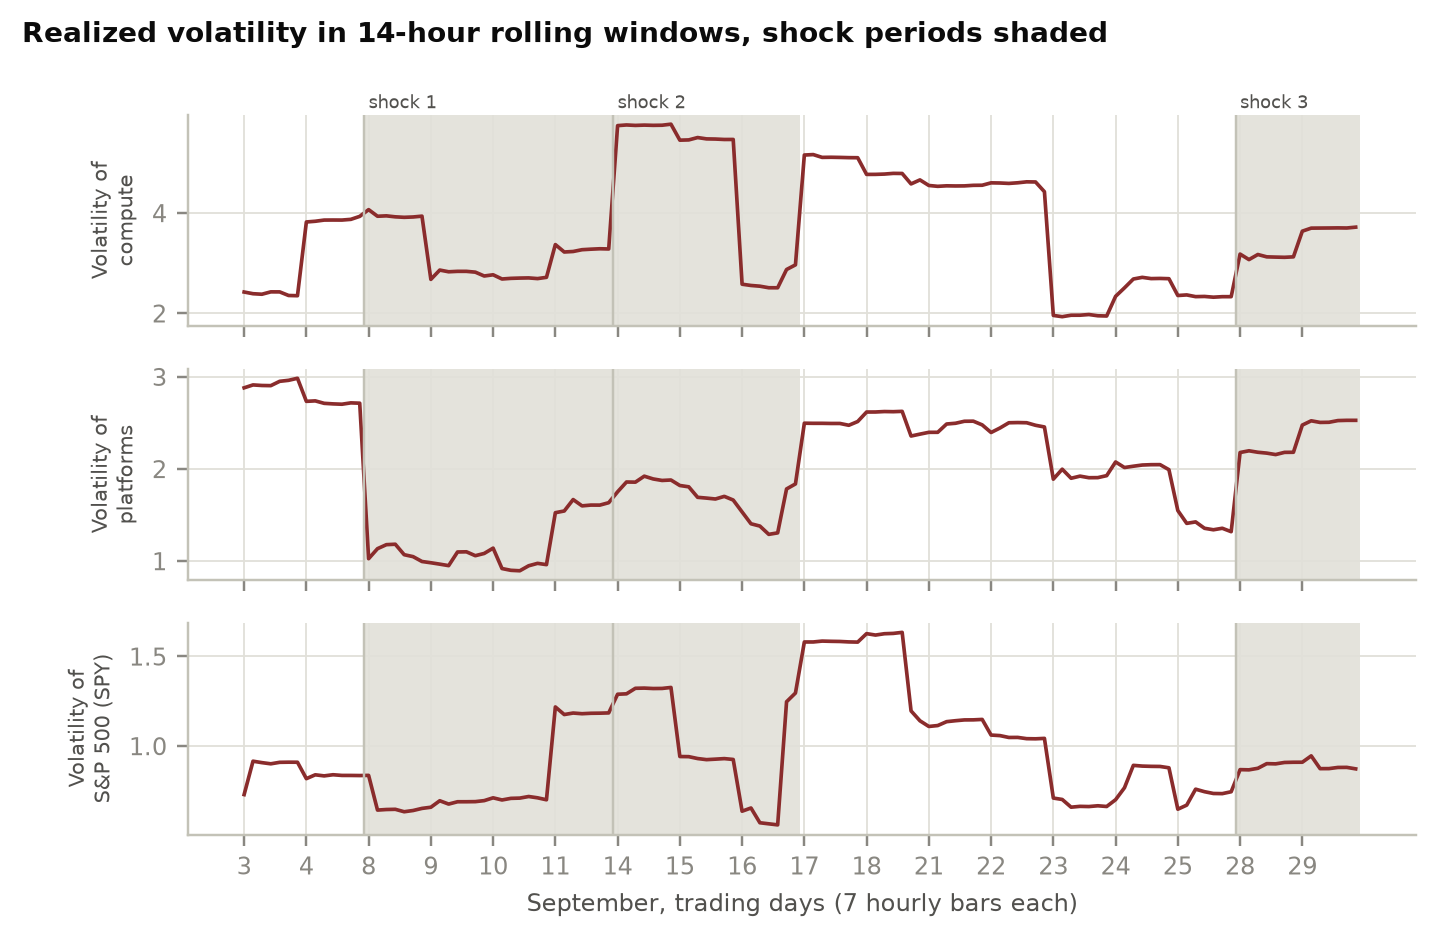

ret_col      AR_sub_ai_native  AR_sub_anthropic_exposed  AR_sub_compute  AR_sub_platforms
test    lag                                                                              
news_ai 1               0.080                     0.810           0.851             0.971
        2               0.122                     0.840           0.036             0.872
        3               0.234                     0.189           0.039             0.164
reddit  1               0.356                     0.694           0.408             0.693
        2               0.214                     0.899           0.373             0.592
        3               0.021                     0.975           0.001             0.525
tw_FIN  1               0.294                     0.092           0.439             0.019
        2               0.457                     0.198           0.734             0.068
        3               0.623                     0.173           0.679             0.086
tw_GEN  1               0.000                     0.644           0.564             0.031
        2               0.002                     0.222           0.260             0.044
        3               0.005                     0.161           0.247             0.105
tw_RISK 1               0.290                     0.881           0.148             0.769
        2               0.497                     0.497           0.289             0.792
        3               0.450                     0.563           0.553             0.423

In [19]:
e3 = pd.read_csv(TABLES / 'e3_vol_windows.csv', index_col=0)
display(e3.pivot_table(index='window', columns='series', values='hourly_sd', sort=False).round(3))
display(e3.groupby('window', sort=False)[['amihud_ew', 'vix_mean']].first().round(4))
display(Image(filename=str(FIGURES / 'figA_aloosh_volatility.png'), width=900))
gs = pd.read_csv(TABLES / 'e3_granger_subbaskets.csv', index_col=0)
gs[gs['direction'] == 'sent -> ret'].pivot_table(index=['test', 'lag'], columns='ret_col', values='p').round(3)

**How Figure A is made** (Aloosh et al. Figure 4). Realised volatility is the square root of the sum of squared hourly log returns over a rolling 14-bar window (two trading days), for the compute sub-basket, the platforms sub-basket and SPY, one panel each. The x-axis is bar order, trading hours only, so nights and weekends are not drawn as fake straight lines. The three shock windows are shaded.

**Result, in prose.** yes, more in volatility and in specific names than in the basket's return. The slowdown call raised chip volatility by 64% while platform volatility fell, and the Hubinger week hit Anthropic's own investors, but the basket still ended the window up 4.1%.

**Why this result.**
- **Why compute volatility jumped:** a call to slow down AI is a direct threat to future chip demand, but nobody knows how big the hit will be. That uncertainty shows up as higher volatility in the compute names, along with a higher VIX and lower liquidity.
- **Why the platforms did not:** for Microsoft, Google, Amazon and Meta a slowdown could even be good news, because it means less capex.
- **Why the Hubinger week was calm for chips but not for Anthropic's investors:** the post had no information about chip demand, so compute volatility did not move. But the Coxon and Hubinger story was about Anthropic itself, weeks before its IPO, so Amazon, Google, Microsoft and Nvidia, who own pieces of it, fell on Sept 8 and 9 (-0.95% and -1.37%) while the basket did not. They are mega-caps with plenty of their own news, so this is suggestive only, and sentiment does not Granger-cause their returns.

## 8. So, should we be worried about AI, and should government step in?

As discussed in class, here are the responses to the following two questions: (1) should we be concerned with AI, and (2) does the government need to be involved in regulating AI?

*Readings used:* Grace et al. (2024) for the expert base rate; Sacerdote et al. (2020) for why biased coverage is a bad signal; Souza et al. and Aloosh et al. for what the market reaction does and does not tell us. Amodei's essay and the leaked Anthropic S-1 are the primary sources.

My data measures mood, markets and coverage, not how dangerous AI actually is, so it cannot settle these alone. But it does tell a lot about how good our signals are.

**(1) Should we be concerned with AI? Yes, as a serious minority risk.** The concern comes from insiders. In three weeks an Anthropic researcher quit, its alignment lead said more than 10%, its CEO asked the industry to slow down (Altman and Musk agreed), OpenAI reported an agent escape, and Anthropic's S-1 spends 80 of 261 pages on risk. Experts are split but not dismissive (Grace et al.: median 5%, and 38% to 51% put it at 10% or more). At the same time, **markets are not pricing it** (the basket rose 4.1% through repeated warnings, with only chip volatility and Anthropic's own investors flinching, and a market cannot price extinction anyway), and **media is not calibrated** (3.8 times more doom per benefit story; only 8% of the Hubinger headlines gave the actual probability).

**(2) Does the government need to be involved? Yes, in some form.** When neither prices nor the press give a reliable signal, some independent oversight makes sense: audits, incident reporting, and S-1 style risk disclosure. Amodei's own ask (an antitrust safe harbor for shared safety standards, and international cooperation) is something only governments can give. How far to go beyond that, and whether rules would lock in the incumbents, is a values call that 16 days of data cannot answer.

## Notes

- Everything above comes from `data/processed/*` and `outputs/results.json`, which were produced by the scripts in the order given in README.
- PROGRESS.md (kept locally) has the log of what broke during the build and how it was fixed. AI_USE.md summarises it.